# Set up simulations and data

## read in libraries

In [57]:
import sys
sys.path.append(r"C:\GitHubRepos\APSIMTools\GraphLib")

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# graph models
from apsim_tools.graphing import (
    plot_obs_pred_by_branch,
    plot_stage_timeseries
)

from apsim_tools.style import ( 
    Colors, 
    Markers,
    Lines
)

from apsim_tools.runner import (
    load_all,
    validate_run_branches,
    to_tidy
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Branch and file Settings

In [58]:
# ======================
# CONFIG
# ======================
BRANCHES = {
    "master": "Lentil",
}

# ======================
# RUN CONTROL - Specify which branches to (re)run
# ======================

# Options:
#RUN_BRANCHES = []                    # run nothing (use existing DBs)
RUN_BRANCHES = list(BRANCHES.keys())   # run all branches
#RUN_BRANCHES = ["master"]
#RUN_BRANCHES = ["working"]
#RUN_BRANCHES = ["working V2"]

REPO_PATH = Path(r"C:\GitHubRepos\ApsimX")

SIM_FILES = [
    Path(REPO_PATH) / 'Prototypes/Lentil/Lentil.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/FAHMA/FAHMA_Lentil.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2019_NSW_Greenethorpe_Mixed_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_Vic_Kalkee_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_SA_Riverton_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_Methul_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_Vic_Ouyen_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_RankinsSprings_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_SA_Pinery_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Vic_Dooen_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Vic_Ouyen_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Qld_Gatton_Mixed_Light.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_NSW_Greenethorpe_Mixed_NFix.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_Vic_Walpeup_Lentil_Satellite.apsimx'
]


CONFIG = {
    "branches": BRANCHES,
    "run_branches": RUN_BRANCHES,
    "sim_files": SIM_FILES,
    "repo_path": Path(r"C:\GitHubRepos\ApsimX"),
    "apsim_exe": r"C:\GitHubRepos\ApsimX\bin\Release\net8.0\Models.exe",
    "apsim_solution": r"C:\GitHubRepos\ApsimX\ApsimX.sln",
    "stage_var": "Lentil.Phenology.Stage",
    "stage_name_var": "Lentil.Phenology.CurrentStageName",
    "harvest_stage": "HarvestRipe",
    "cultivar_col": "Lentil.SowingData.Cultivar"
}

validate_run_branches(config=CONFIG)

## additional index mapping

In [59]:
# Specifiy map for cultivars to winter or spring type
project_group={
 'Caragabal19':'Historic',
 'Emerald19':'Historic',
 'Gatton19':'Historic',
 'Greenethorpe19':'Historic',
 'GreenethorpePhen19':'Historic',
 'Mildura19':'Historic',
 'Millmerran19':'Historic',
 'Walgett19':'Historic',
 'Wellcamp25':'FAHMA',
 'Roberts1988':'ContEnv',
 'Roberts1986':'ContEnv',
 'Summerfield1985':'ContEnv',
 'Rajandran2022':'ContEnv',
 'Dooen2001':'Historic',
 'Roseworthy':'Historic',
 'Gatton24':'FAHMA',
 'Gatton23':'FAHMA',
 'ForestHill25':'FAHMA',
 '2019_NSW_Greenethorpe_Mixed_Detailed':'NaPA',
 '2022_Vic_Kalkee_Lentil_Detailed':'NaPA',
 '2022_SA_Riverton_Lentil_Detailed':'NaPA',
 '2022_NSW_WaggaWagga_Lentil_Detailed':'NaPA',
 '2022_NSW_Methul_Lentil_Satellite':'NaPA',
 '2022_Vic_Ouyen_Lentil_Satellite':'NaPA',
 '2022_NSW_RankinsSprings_Lentil_Satellite':'NaPA',
 '2022_SA_Warnertown_Lentil_Satellite':'NaPA',
 '2023_SA_Pinery_Lentil_Detailed':'NaPA',
 '2023_Vic_Dooen_Lentil_Detailed':'NaPA',
 '2023_SA_Warnertown_Lentil_Satellite':'NaPA',
 '2023_Vic_Ouyen_Lentil_Satellite':'NaPA',
 '2023_Qld_Gatton_Mixed_Light':'NaPA',
 '2024_NSW_Greenethorpe_Mixed_NFix':'NaPA',
 '2024_SA_Warnertown_Lentil_Satellite':'NaPA',
 '2024_Vic_Walpeup_Lentil_Satellite':'NaPA',
}

# Pack maps together ready to be inserted as indexes 
additional_index_maps = {
    "ProjectGroup": {
        "source": "Experiment",
        "map": project_group
    }
}

## Write file for command line tool to apply to each .apsimx file to be run.
If you want to make standard modifications to all files run it can be done here

In [60]:
def write_apply_file(sim_file):
    """
    Create an APSIM CLI apply file which:
    - removes specified reports
    - injects AnalysisReport
    - sets variables
    - saves and runs simulation
    """
    report_library = r"C:/GitHubRepos/ApsimX/Prototypes/Lentil/Report_lib.apsimx"
    apply_file = sim_file.with_name(f"_apply_{sim_file.stem}.txt")

    lines = []

    # ---------------------------------------------
    # Add AnalysisReport to all Simulation nodes
    # ---------------------------------------------
    lines.append(f"add [AnalysisReport] from {report_library} to all [Zone]")
    
    # ---------------------------------------------
    # Inject Spectral model into each simulation
    # ---------------------------------------------
    # lines.append("add [Spectral] to all [Zone]")

    # ---------------------------------------------
    # Save + run
    # ---------------------------------------------
    lines.append(f"save {sim_file}")
    lines.append(f"run {sim_file}")

    # Write file
    apply_file.write_text("\n".join(lines))

    return apply_file

## Run simulations and read in raw .db data and process into tidy format

In [61]:
# ======================
# EXECUTE PIPELINE
# ======================

# Read in raw data
raw = load_all(config=CONFIG, apply_fn=write_apply_file)

# ✅ Ensure SimulationName exists (from AnalysisReport)
if "Simulation.Name" in raw.columns:
    raw = raw.rename(columns={"Simulation.Name": "SimulationName"})

# ✅ Convert to tidy format
tidy = to_tidy(raw, config=CONFIG, additional_index_maps=additional_index_maps)

🔄 Resetting tracked files only

▶ Running APSIM [master]: Lentil.apsimx
▶ Running APSIM: Lentil.apsimx

Lentil.apsimx tables: ['_Factors', '_InitialConditions', 'DailyReport', 'SowingReport', '_Messages', 'HarvestReport', '_Simulations', '_Checkpoints', '_Units', 'HarvestObsPred', 'DailyObsPred', 'AnalysisReport', 'spec', 'specdaily', 'SupReport', 'Report', 'Observed', 'Roberts_etal_1988', 'Summerfield_etal_1985', 'Roberts_etal_1986']

⚠️ Missing observed simulations in Lentil.apsimx: 48

⚠️ Dropping unmatched observed simulations in Lentil.apsimx: 105
✅ Obs filtered by SimulationID: 2851/4650 rows kept

▶ Running APSIM [master]: FAHMA_Lentil.apsimx
▶ Running APSIM: FAHMA_Lentil.apsimx

FAHMA_Lentil.apsimx tables: ['_Factors', '_InitialConditions', 'DailyReport', 'SowingReport', '_Messages', 'HarvestReport', '_Simulations', '_Checkpoints', '_Units', 'HarvestObsPred', 'DailyObsPred', 'AnalysisReport', 'Observed']
✅ Obs filtered by SimulationID: 338/338 rows kept

▶ Running APSIM [master

# Harvest predictions

## Phenology

### Budding DAS

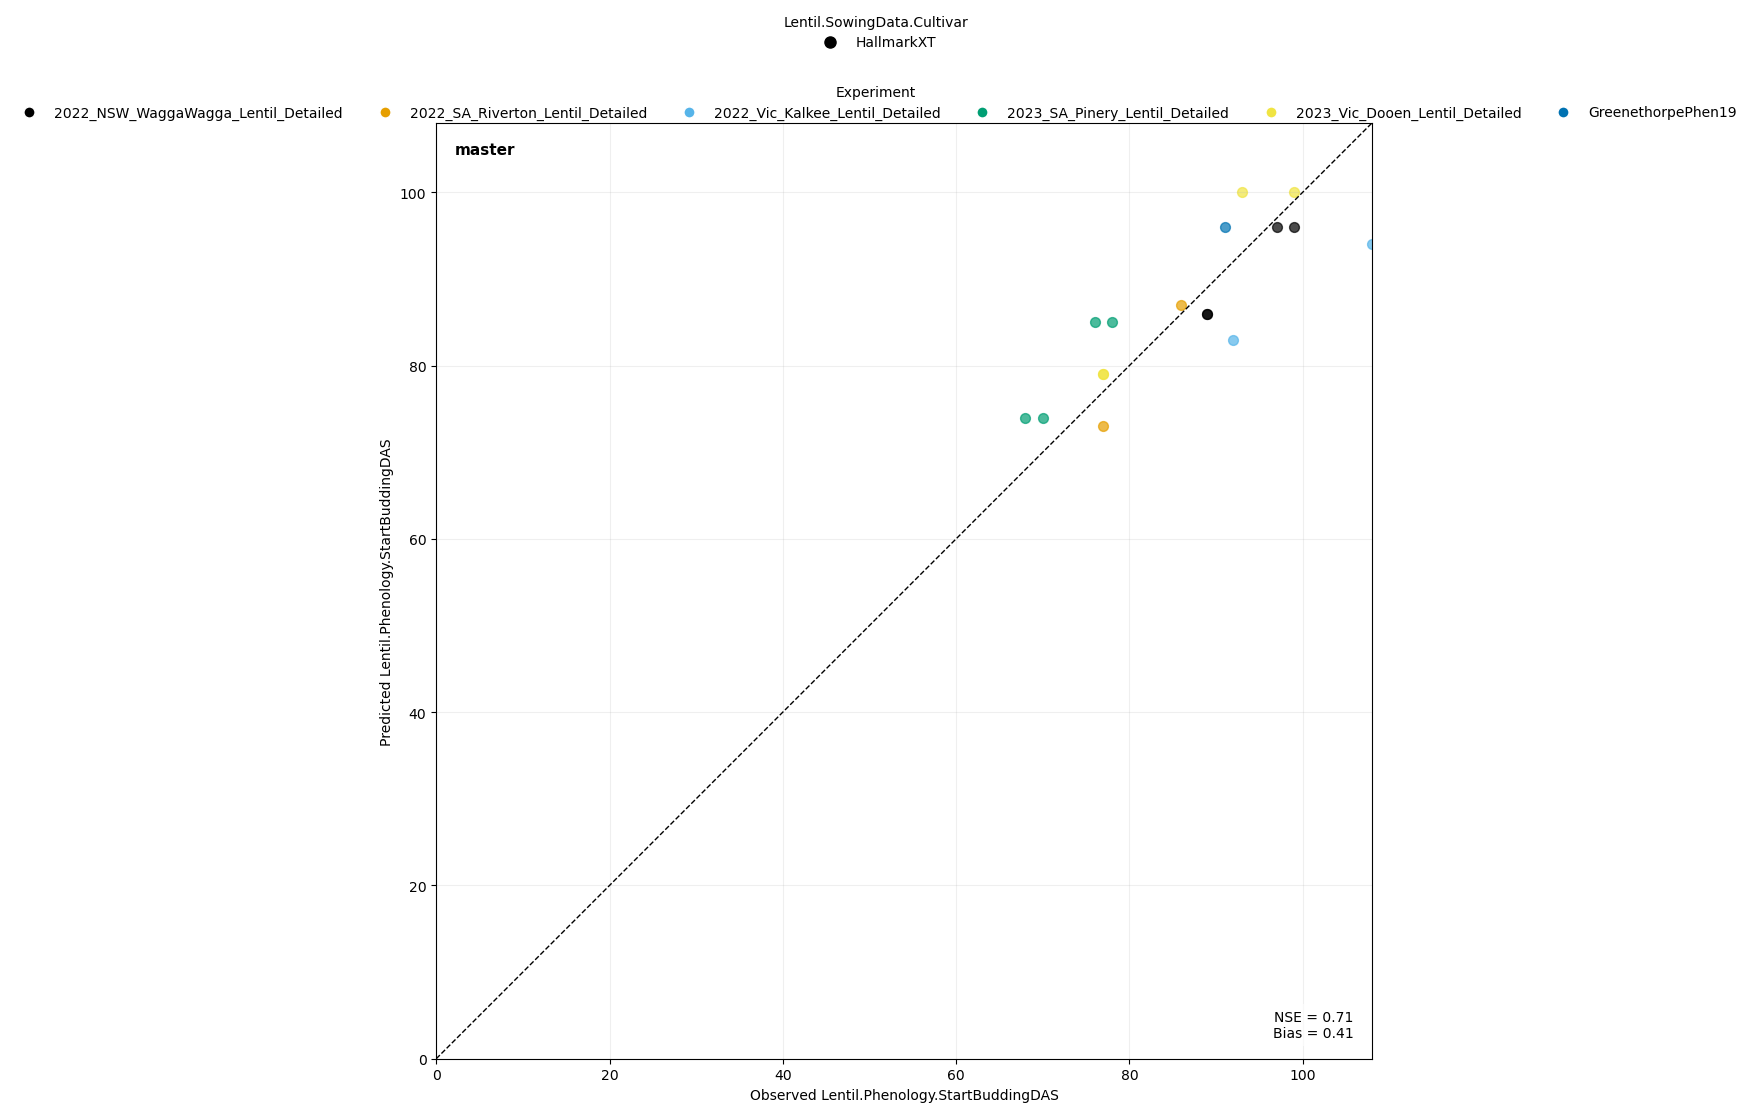

In [62]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Phenology.StartBuddingDAS",
    mode='harvest',
    filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    color_by = "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

### Flowering DAS

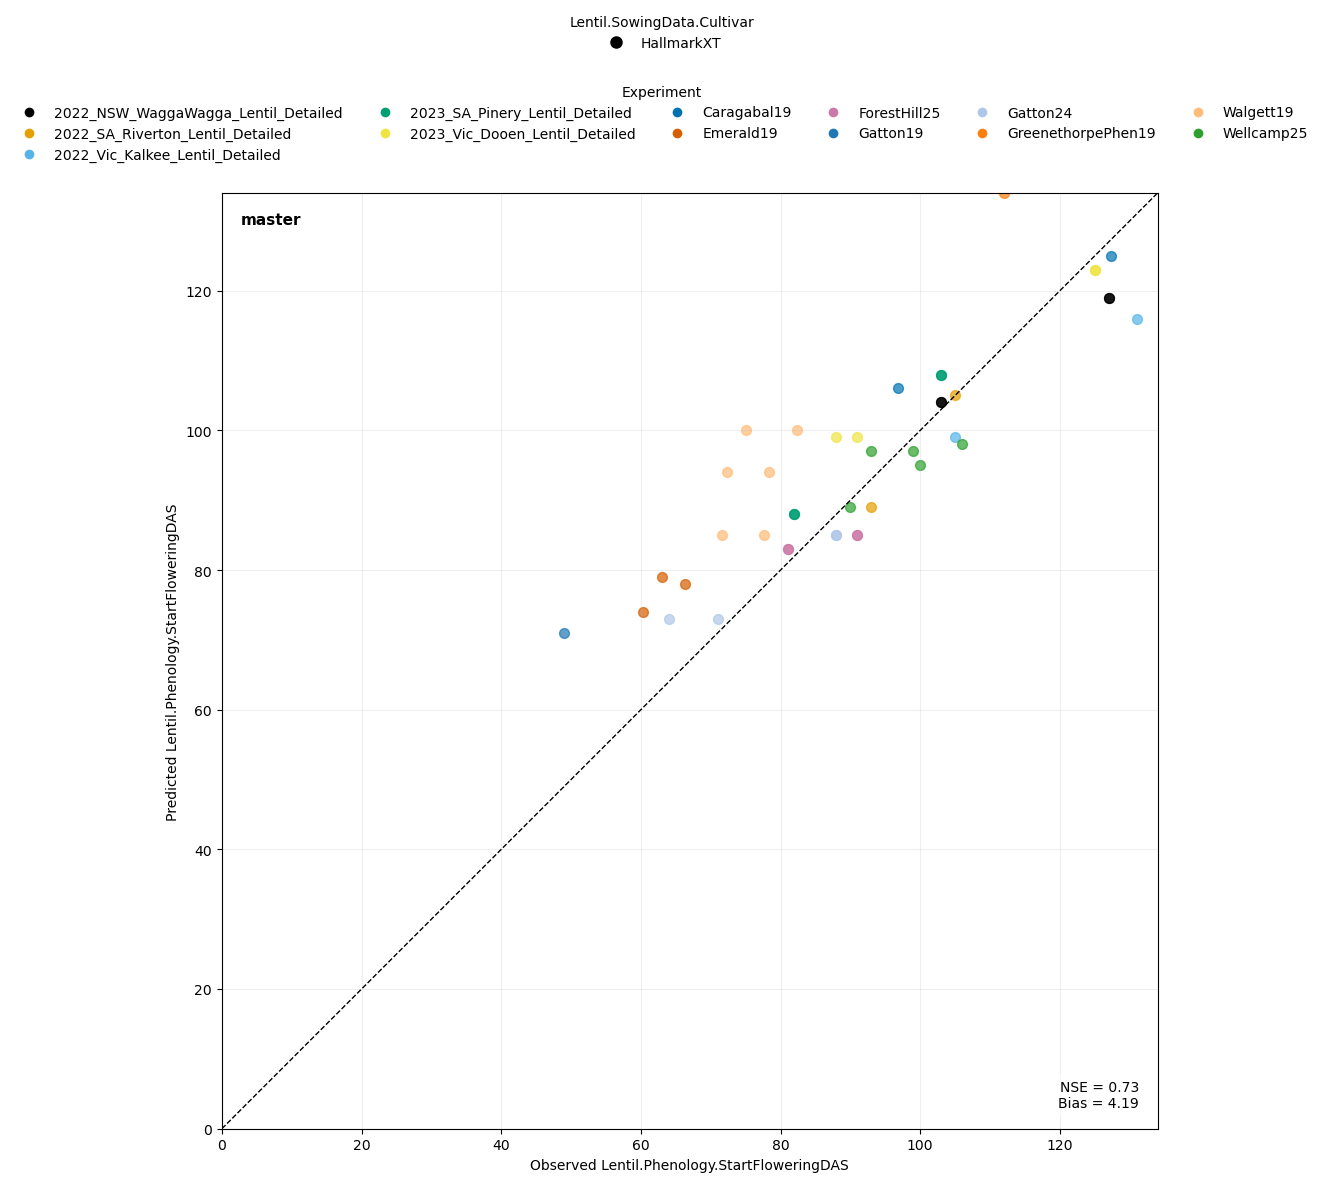

In [63]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Phenology.StartFloweringDAS",
    mode='harvest',
    filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    color_by = "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

### Podding DAS

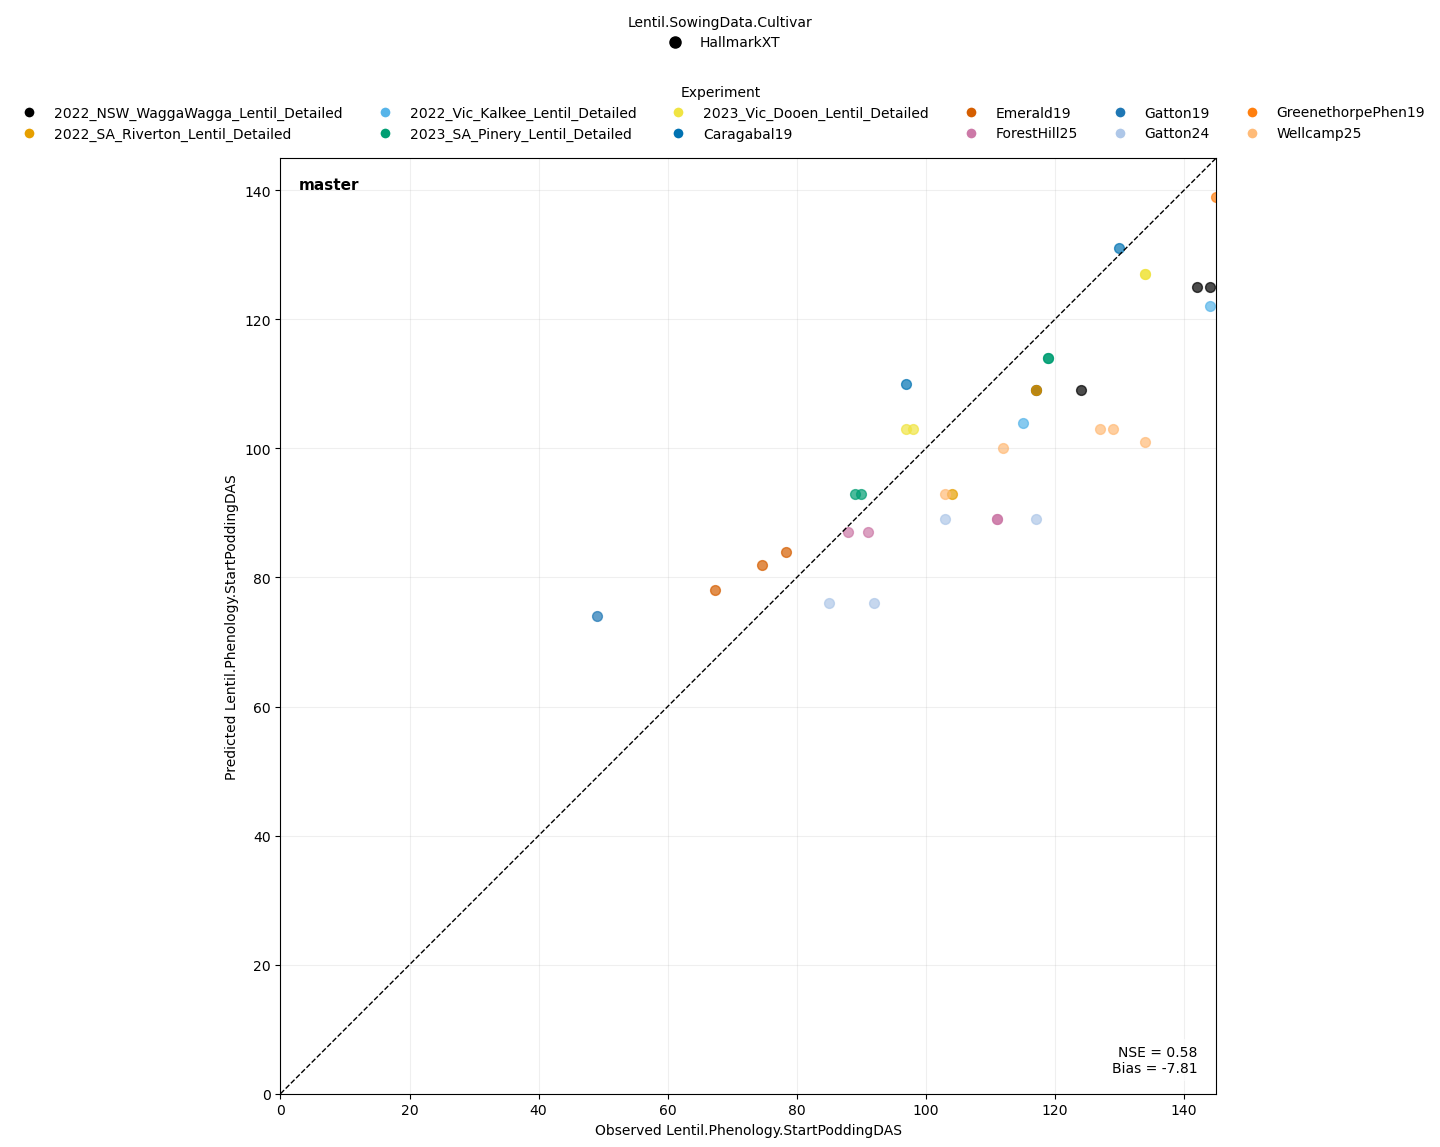

In [64]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Phenology.StartPoddingDAS",
    mode='harvest',
    filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    color_by = "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

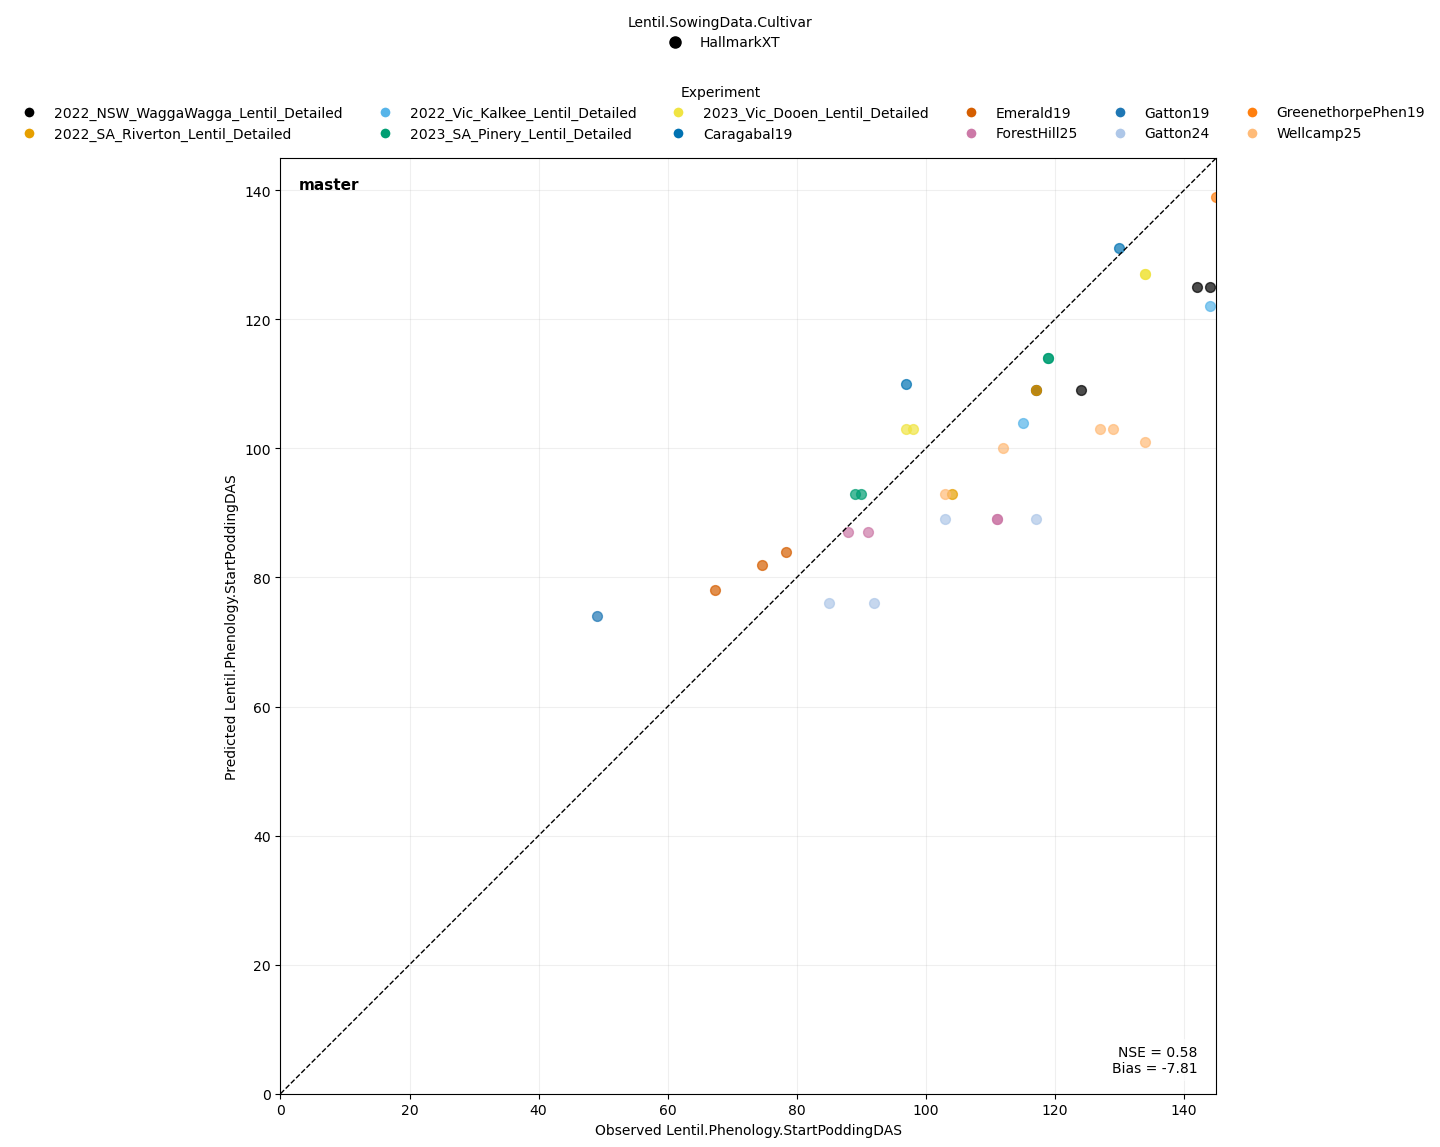

In [65]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Phenology.StartPoddingDAS",
    mode='harvest',
    filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    color_by = "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

## Grain

### Yield (g/m2)

C:\Users\Cflhxb\AppData\Local\miniforge3\envs\sim_env\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Cflhxb\AppData\Local\miniforge3\envs\sim_env\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


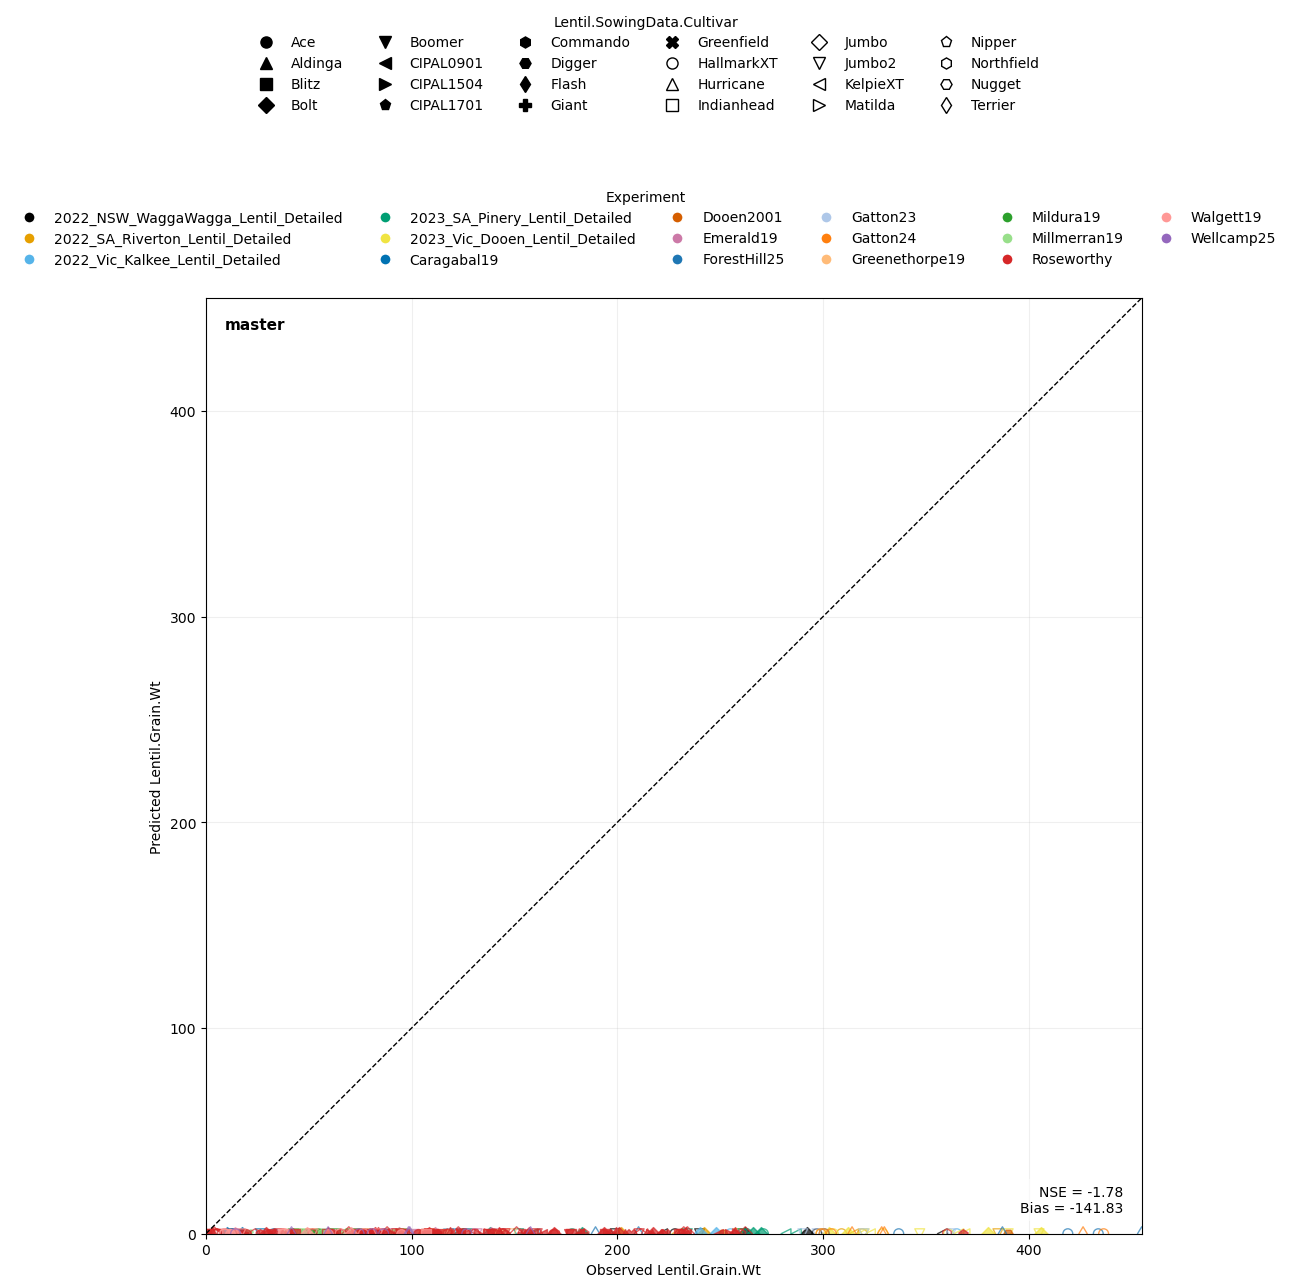

In [66]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Grain.Wt",
    mode='harvest',
    #filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    color_by = "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

### Grain number

In [86]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Grain.Number",
    mode='harvest',
    #filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    color_by = "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

ZeroDivisionError: division by zero

## Biomas

### Above ground Wt (g/m2)

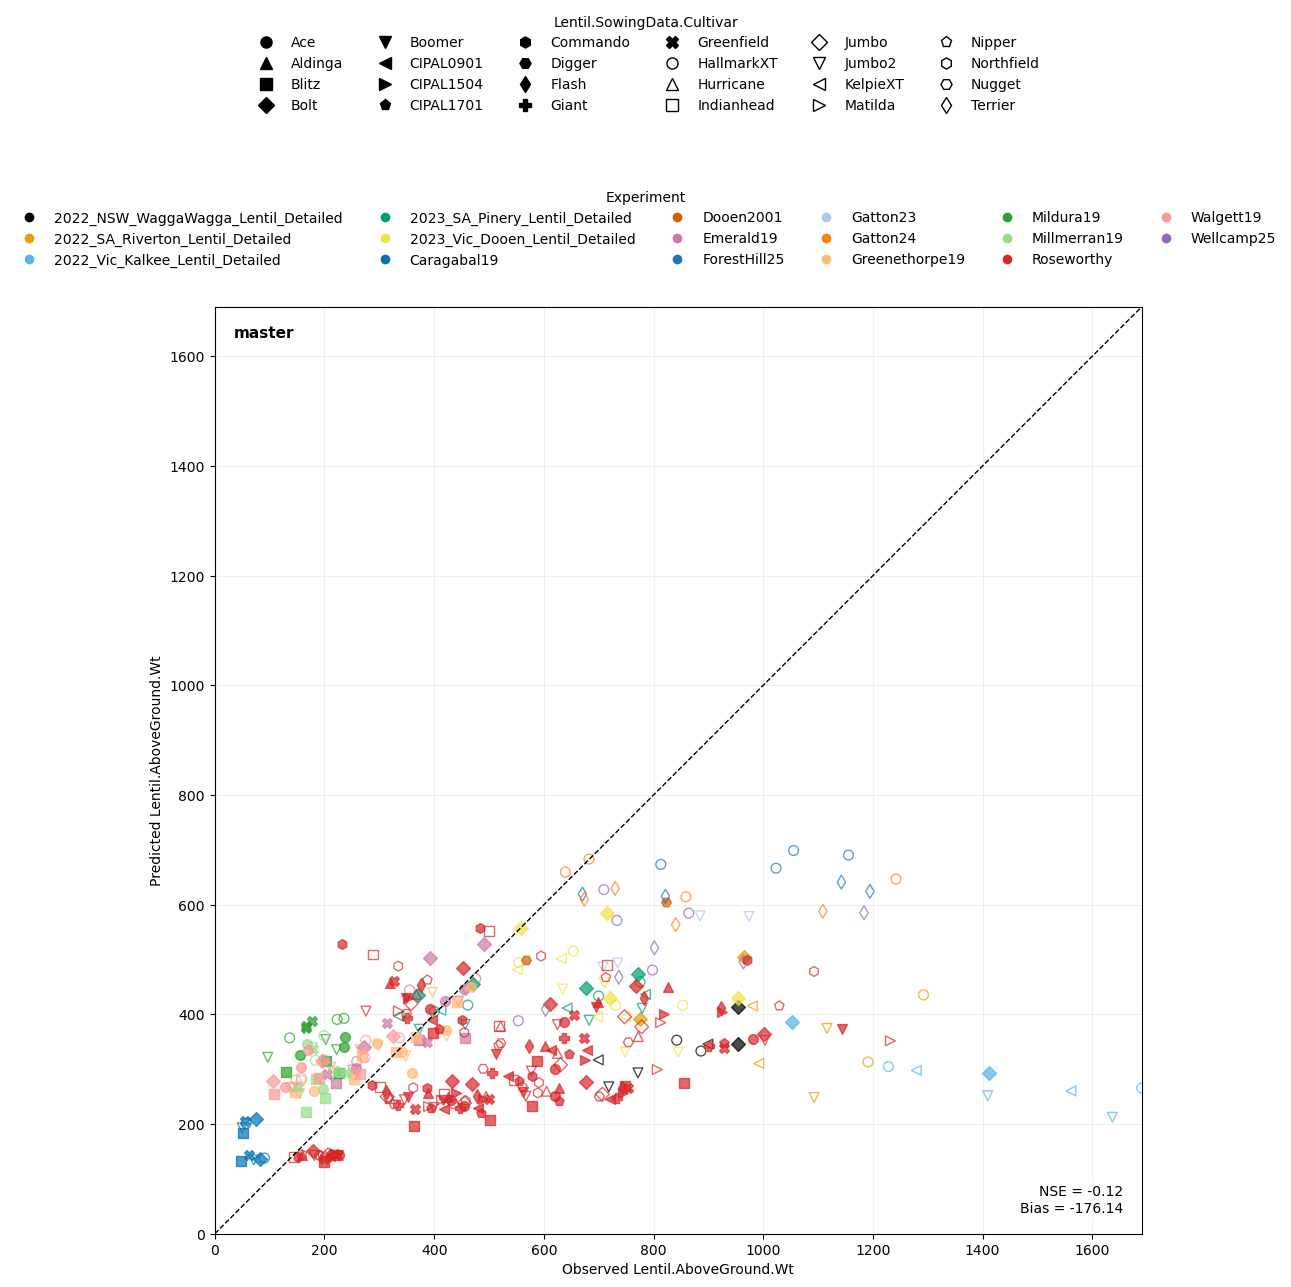

In [67]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.AboveGround.Wt",
    mode='harvest',
    #filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    color_by = "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

# Work out list of files to run for each cultivar for phenology fitting

In [68]:
obs = tidy[tidy.type=='obs']
phenVars = ['Lentil.Phenology.StartBuddingDAS',
             'Lentil.Phenology.StartFloweringDAS',
             'Lentil.Phenology.StartPoddingDAS']
phenObs = obs[obs.variable.isin(phenVars)]

In [69]:
phenObs#[phenObs.file=="2024_Vic_Walpeup_Lentil_Satellite.apsimx"]

,CheckpointID,SimulationID,Experiment,Zone,Clock.Today,SimulationName,Lentil.Phenology.CurrentStageName,Lentil.SowingData.Cultivar,type,branch,file,variable,value,ProjectGroup
14103505,1,56,Gatton19,NaN,2019-06-12 00:00:00,Gatton19TOS2CvBlitz,Emergence,Blitz,obs,master,Lentil.apsimx,Lentil.Phenology.StartBuddingDAS,51.0,Historic
14103511,1,56,Gatton19,NaN,2019-07-28 00:00:00,Gatton19TOS2CvBlitz,StartFlowering,Blitz,obs,master,Lentil.apsimx,Lentil.Phenology.StartBuddingDAS,49.0,Historic
14103512,1,56,Gatton19,NaN,2019-09-08 00:00:00,Gatton19TOS2CvBlitz,HarvestRipe,Blitz,obs,master,Lentil.apsimx,Lentil.Phenology.StartBuddingDAS,51.0,Historic
14103536,1,60,Gatton19,NaN,2019-06-12 00:00:00,Gatton19TOS2CvJumbo2,Emergence,Jumbo2,obs,master,Lentil.apsimx,Lentil.Phenology.StartBuddingDAS,44.0,Historic
14103541,1,60,Gatton19,NaN,2019-07-21 00:00:00,Gatton19TOS2CvJumbo2,StartFlowering,Jumbo2,obs,master,Lentil.apsimx,Lentil.Phenology.StartBuddingDAS,42.0,Historic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14593466,1,1,2023_Vic_Dooen_Lentil_Detailed,NaN,NaN,2023_Vic_Dooen_Lentil_DetailedTOSTOS2VarietyHa...,HarvestRipe,HallmarkXT,obs,master,2023_Vic_Dooen_Lentil_Detailed.apsimx,Lentil.Phenology.StartPoddingDAS,97.0,NaPA
14593467,1,77,2023_Vic_Dooen_Lentil_Detailed,NaN,NaN,2023_Vic_Dooen_Lentil_DetailedTOSTOS2VarietyJu...,HarvestRipe,Jumbo2,obs,master,2023_Vic_Dooen_Lentil_Detailed.apsimx,Lentil.Phenology.StartPoddingDAS,98.0,NaPA
14593468,1,78,2023_Vic_Dooen_Lentil_Detailed,NaN,NaN,2023_Vic_Dooen_Lentil_DetailedTOSTOS2VarietyJu...,HarvestRipe,Jumbo2,obs,master,2023_Vic_Dooen_Lentil_Detailed.apsimx,Lentil.Phenology.StartPoddingDAS,99.0,NaPA
14593469,1,79,2023_Vic_Dooen_Lentil_Detailed,NaN,NaN,2023_Vic_Dooen_Lentil_DetailedTOSTOS2VarietyKe...,HarvestRipe,KelpieXT,obs,master,2023_Vic_Dooen_Lentil_Detailed.apsimx,Lentil.Phenology.StartPoddingDAS,96.0,NaPA


In [70]:
phenFrame = phenObs.groupby(['Lentil.SowingData.Cultivar','file']).count().index.to_frame()

In [71]:
CvList = phenFrame.index.get_level_values(0).drop_duplicates().values

In [72]:
CvFileDict = {}

for Cv in CvList:
    CvFileDict[Cv] = phenFrame.loc[Cv,'file'].drop_duplicates().to_list()

In [73]:
CvFileDict

{'Ace': ['Lentil.apsimx'],
 'Aldinga': ['Lentil.apsimx'],
 'Blitz': ['Lentil.apsimx'],
 'Bolt': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx',
  'Lentil.apsimx'],
 'Boomer': ['Lentil.apsimx'],
 'CIPAL0901': ['Lentil.apsimx'],
 'CIPAL1504': ['Lentil.apsimx'],
 'CIPAL1701': ['Lentil.apsimx'],
 'Commando': ['Lentil.apsimx'],
 'Ethiopian': ['Lentil.apsimx'],
 'Flash': ['Lentil.apsimx'],
 'Giant': ['Lentil.apsimx'],
 'Greenfield': ['Lentil.apsimx'],
 'HallmarkXT': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx',
  'FAHMA_Lentil.apsimx',
  'Lentil.apsimx'],
 'Hurricane': ['Lentil.apsimx'],
 'Indianhead': ['Lentil.apsimx'],
 'Jumbo': ['Lentil.apsimx']

In [74]:

obs_raw = raw[raw["type"] == "obs"]

cols = obs_raw.columns
print(cols)

obs_raw.head(20)


Index(['CheckpointID', 'SimulationID', 'Experiment', 'FolderName', 'InitT',
       'InitPp', 'Durat', 'FinalT', 'FinalPp', 'Cv',
       ...
       'Delta13C', 'Delta13C_se', 'Lentil.AboveGround.WtSE',
       'Lentil.Grain.Wtse', 'Lentil.Grain.HarvestIndexse',
       'Lentil.Pod.Number_se', 'Lentil.Grain.Number_se',
       'Lentil.Pod.SeedNumber', 'Soil.Water.Volumetric(12)', 'Agronomy'],
      dtype='str', length=150)


,CheckpointID,SimulationID,Experiment,FolderName,InitT,InitPp,Durat,FinalT,FinalPp,Cv,...,Delta13C,Delta13C_se,Lentil.AboveGround.WtSE,Lentil.Grain.Wtse,Lentil.Grain.HarvestIndexse,Lentil.Pod.Number_se,Lentil.Grain.Number_se,Lentil.Pod.SeedNumber,Soil.Water.Volumetric(12),Agronomy
201830,1,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201831,1,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201832,1,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201833,1,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201834,1,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201835,1,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201836,1,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201837,1,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201838,1,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201839,1,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:

obs_raw[
    obs_raw["file"] == "2024_Vic_Walpeup_Lentil_Satellite.apsimx"
].head(20)


,CheckpointID,SimulationID,Experiment,FolderName,InitT,InitPp,Durat,FinalT,FinalPp,Cv,...,Delta13C,Delta13C_se,Lentil.AboveGround.WtSE,Lentil.Grain.Wtse,Lentil.Grain.HarvestIndexse,Lentil.Pod.Number_se,Lentil.Grain.Number_se,Lentil.Pod.SeedNumber,Soil.Water.Volumetric(12),Agronomy


In [76]:

raw_obs = raw[raw["type"] == "obs"]

sat_obs = raw_obs[
    raw_obs["file"] == "2024_Vic_Walpeup_Lentil_Satellite.apsimx"
].copy()


In [77]:

# columns that could contain real observations

# ONLY variables you actually care about
obs_vars = [
    'Lentil.Phenology.StartBuddingDAS',
    'Lentil.Phenology.StartFloweringDAS',
    'Lentil.Phenology.StartPoddingDAS'
]

value_cols = [c for c in obs_vars if c in sat_obs.columns]


# detect rows with any non-NaN values
has_real_data = sat_obs[value_cols].notna().any(axis=1)

print("Rows with real data:", has_real_data.sum())
print("Total rows:", len(sat_obs))


Rows with real data: 0
Total rows: 0


In [78]:
sat_obs[value_cols]

,Lentil.Phenology.StartBuddingDAS,Lentil.Phenology.StartFloweringDAS,Lentil.Phenology.StartPoddingDAS


In [79]:
import sqlite3
db_file =  Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_Vic_Walpeup_Lentil_Satellite.db'
with sqlite3.connect(db_file) as conn:
    df = pd.read_sql(f"SELECT * FROM Observed", conn)

In [80]:
df.columns

Index(['CheckpointID', 'SimulationID', 'Clock.Today', 'HarvestNo',
       'Lentil.Phenology.CurrentStageName', 'id',
       'Lentil.Phenology.StartBuddingDAS', 'Lentil.Phenology.StartPoddingDAS',
       'Lentil.Phenology.StartFloweringDAS', 'Lentil.Phenology.MaturityDAS',
       'Lentil.Leaf.NodeNumber', 'Ndfa_prop', 'Ndfa_prop_se',
       'NfixIntensity_mg_gDM', 'NfixIntensity_mg_gDM_se',
       'Lentil.AboveGround.N', 'Lentil.AboveGround.N_se', 'Delta13C',
       'Delta13C_se', 'Lentil.AboveGround.Wt', 'Lentil.AboveGround.WtSE',
       'Lentil.Grain.Wt', 'Lentil.Grain.Wtse', 'Lentil.Grain.HarvestIndex',
       'Lentil.Grain.HarvestIndexse', 'Lentil.Pod.Number',
       'Lentil.Pod.Number_se', 'Lentil.Grain.Number', 'Lentil.Grain.Number_se',
       'Lentil.Grain.Size', 'Lentil.Pod.SeedNumber'],
      dtype='str')

In [81]:
df.SimulationID.drop_duplicates()

0       9
1      10
2      11
3      12
4      13
       ..
76     85
77     86
78     87
79     88
625    89
Name: SimulationID, Length: 81, dtype: int64

In [82]:
import sqlite3
db_file =  Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_Vic_Walpeup_Lentil_Satellite.db'
with sqlite3.connect(db_file) as conn:
    df = pd.read_sql(f"SELECT * FROM AnalysisReport", conn)

In [83]:
df.SimulationID.drop_duplicates()

0      3
100    8
200    1
300    4
400    2
500    7
600    6
700    5
Name: SimulationID, dtype: int64

### 